<center><h1>MINERIA DE DATOS</h1>
<strong>Taller Distancias</strong><br />
PROFESORA ELIZABETH LEON GUZMAN <br />
<strong>TEMA</strong> Distancias</center>

**Nombre:** Angel David Piñeros Sierra  
**Semestre:** 2026-1  
**Materia:** Mineria de Datos  
**Fecha:** 27 de Abril de 2026

-------

## Distancias

Dados los ejemplos numéricos A={1,0,2,5,3} y B={2,1,0,3,-1}, encontrar:

a) La distancia euclideana

b) La distancia city-block

c) La distancia Minkowski para p=3

In [25]:
from math import sqrt
from scipy.spatial.distance import cityblock, minkowski, euclidean
import pandas as pd

#Carga de datos:
A = [1,0,2,5, 3]
B = [2,1,0,3,-1]

# Calculamos la similitud entre cada punto del dataset
distancias = [[euclidean(A,B), cityblock(A,B), minkowski(A,B, p=3)]]
d = pd.DataFrame(distancias,columns=['euclideana','cityblock','minkowski'])
d

,euclideana,cityblock,minkowski
0,5.09902,10,4.344481


**Ejercicio 1**
1. Calcular la distancia coseno, correlacion y chevishev
2. ¿Qué puede decir de los resultados de las diferentes distancias? Incluyendo las incluidas en el ejemplo


In [26]:
def to_vector(values):
    if hasattr(values, 'tolist'):
        values = values.tolist()
    if isinstance(values, (list, tuple)) and len(values) == 1 and isinstance(values[0], (list, tuple)):
        values = values[0]
    return [float(x) for x in values]

vector_a = to_vector(A)
vector_b = to_vector(B)

if len(vector_a) != len(vector_b):
    raise ValueError('A y B deben tener la misma dimension')

def euclidean_distance(u, v):
    return sqrt(sum((x - y) ** 2 for x, y in zip(u, v)))

def cityblock_distance(u, v):
    return sum(abs(x - y) for x, y in zip(u, v))

def minkowski_distance(u, v, p):
    return sum(abs(x - y) ** p for x, y in zip(u, v)) ** (1 / p)

def cosine_distance(u, v):
    dot = sum(x * y for x, y in zip(u, v))
    norm_u = sqrt(sum(x ** 2 for x in u))
    norm_v = sqrt(sum(y ** 2 for y in v))
    return 1 - dot / (norm_u * norm_v)

def correlation_distance(u, v):
    mean_u = sum(u) / len(u)
    mean_v = sum(v) / len(v)
    centered_u = [x - mean_u for x in u]
    centered_v = [y - mean_v for y in v]
    numerator = sum(x * y for x, y in zip(centered_u, centered_v))
    denominator = sqrt(sum(x ** 2 for x in centered_u)) * sqrt(sum(y ** 2 for y in centered_v))
    return 1 - numerator / denominator

def chebyshev_distance(u, v):
    return max(abs(x - y) for x, y in zip(u, v))

resultados_ejercicio_1 = {
    'euclideana': euclidean_distance(vector_a, vector_b),
    'cityblock': cityblock_distance(vector_a, vector_b),
    'minkowski_p3': minkowski_distance(vector_a, vector_b, 3),
    'coseno': cosine_distance(vector_a, vector_b),
    'correlacion': correlation_distance(vector_a, vector_b),
    'chebyshev': chebyshev_distance(vector_a, vector_b),
}

for nombre, valor in resultados_ejercicio_1.items():
    print(f'{nombre:15} = {valor:.6f}')



euclideana      = 5.099020
cityblock       = 10.000000
minkowski_p3    = 4.344481
coseno          = 0.421171
correlacion     = 0.753402
chebyshev       = 4.000000


**Solucion del ejercicio 1**

- Distancia coseno = `0.421171`, por lo que la similitud coseno es `0.578829`.
- Distancia de correlacion = `0.753402`, lo que implica una correlacion lineal baja entre ambos vectores (`0.246598`).
- Distancia de Chebyshev = `4`, que corresponde a la mayor diferencia absoluta componente a componente.

**Interpretacion de las distancias**

- `City-block` es la mayor porque suma todas las diferencias absolutas entre A y B.
- `Euclideana` resume la separacion global entre los vectores y penaliza mas los desvíos grandes que la city-block.
- `Chebyshev` solo mira la peor discrepancia entre coordenadas; en este caso la mayor diferencia es `4`.
- `Coseno` y `correlacion` no miden magnitud absoluta sino orientacion y patron, por eso muestran una similitud moderada en direccion pero una relacion lineal debil despues de centrar los datos.

**Ejercicio 2**

Se desea encontrar estudiantes similares de acuerdo a las nota que han obtenido en la asignatura. A es el top de estudiantes con notas de 100, 100, 100 para Matemáticas, Química y Computación, respectivamente. B es un estudiante con notas de 50, 50, 50. C es otro estudiante con notas 70, 70, 70. 
¿Cuál es la similitud coseno entre ellos? ¿Cuál es la distancia Euclideana? ¿Qué concluye?

In [27]:
estudiante_a = [100, 100, 100]
estudiante_b = [50, 50, 50]
estudiante_c = [70, 70, 70]

def cosine_similarity(u, v):
    dot = sum(x * y for x, y in zip(u, v))
    norm_u = sqrt(sum(x ** 2 for x in u))
    norm_v = sqrt(sum(y ** 2 for y in v))
    return dot / (norm_u * norm_v)

def euclidean_distance(u, v):
    return sqrt(sum((x - y) ** 2 for x, y in zip(u, v)))

pares_estudiantes = {
    'A-B': (estudiante_a, estudiante_b),
    'A-C': (estudiante_a, estudiante_c),
    'B-C': (estudiante_b, estudiante_c),
}

resultados_ejercicio_2 = {}

for par, (u, v) in pares_estudiantes.items():
    resultados_ejercicio_2[par] = {
        'similitud_coseno': cosine_similarity(u, v),
        'distancia_euclideana': euclidean_distance(u, v),
    }

for par, metricas in resultados_ejercicio_2.items():
    print(par)
    print(f"  similitud_coseno   = {metricas['similitud_coseno']:.6f}")
    print(f"  distancia_euclideana = {metricas['distancia_euclideana']:.6f}")

resultados_ejercicio_2

A-B
  similitud_coseno   = 1.000000
  distancia_euclideana = 86.602540
A-C
  similitud_coseno   = 1.000000
  distancia_euclideana = 51.961524
B-C
  similitud_coseno   = 1.000000
  distancia_euclideana = 34.641016


{'A-B': {'similitud_coseno': 1.0, 'distancia_euclideana': 86.60254037844386},
 'A-C': {'similitud_coseno': 1.0, 'distancia_euclideana': 51.96152422706632},
 'B-C': {'similitud_coseno': 1.0, 'distancia_euclideana': 34.64101615137755}}

**Solucion del ejercicio 2**

- La similitud coseno entre `A-B`, `A-C` y `B-C` es `1.0` en todos los casos.
- Las distancias euclideanas son: `A-B = 86.602540`, `A-C = 51.961524` y `B-C = 34.641016`.

**Interpretación de las distancias**

- Los tres vectores son proporcionales y apuntan en la misma direccion, por eso la similitud coseno es maxima en todos los pares.
- La distancia euclideana si distingue la magnitud de las notas: `B-C` es el par mas cercano y `A-B` es el mas lejano.
- Si el interes es comparar el patron relativo de rendimiento, coseno resulta util; si se quiere comparar la diferencia absoluta en las notas, la euclideana es mas informativa.


**Ejercicio 3**

Se tienen dos objetos (dos puntos) en un espacio bidimensional.

* Calcular la distancia euclideana entre los dos objetos
* Calcular la similitud coseno entre los dos objetos
* Si se normalizan los vectores para que la norma = 1. ¿cuál es la similitud coseno? ¿cuál es la distancia euclideana? ¿Qué concluye?



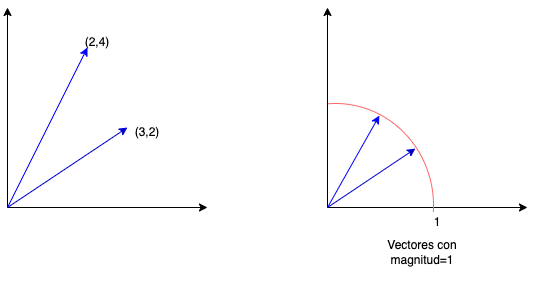

In [28]:
punto_a = [2, 4]
punto_b = [3, 2]

def cosine_similarity(u, v):
    dot = sum(x * y for x, y in zip(u, v))
    norm_u = sqrt(sum(x ** 2 for x in u))
    norm_v = sqrt(sum(y ** 2 for y in v))
    return dot / (norm_u * norm_v)

def euclidean_distance(u, v):
    return sqrt(sum((x - y) ** 2 for x, y in zip(u, v)))

def normalize(u):
    norm_u = sqrt(sum(x ** 2 for x in u))
    return [x / norm_u for x in u], norm_u

a_normalizado, norma_a = normalize(punto_a)
b_normalizado, norma_b = normalize(punto_b)

resultados_ejercicio_3 = {
    'distancia_euclideana': euclidean_distance(punto_a, punto_b),
    'similitud_coseno': cosine_similarity(punto_a, punto_b),
    'norma_a': norma_a,
    'norma_b': norma_b,
    'a_normalizado': a_normalizado,
    'b_normalizado': b_normalizado,
    'similitud_coseno_normalizada': cosine_similarity(a_normalizado, b_normalizado),
    'distancia_euclideana_normalizada': euclidean_distance(a_normalizado, b_normalizado),
}

print(f"Distancia euclideana original = {resultados_ejercicio_3['distancia_euclideana']:.6f}")
print(f"Similitud coseno original = {resultados_ejercicio_3['similitud_coseno']:.6f}")
print(f"Norma de A = {resultados_ejercicio_3['norma_a']:.6f}")
print(f"Norma de B = {resultados_ejercicio_3['norma_b']:.6f}")
print(f"A normalizado = {[round(x, 6) for x in resultados_ejercicio_3['a_normalizado']]}")
print(f"B normalizado = {[round(x, 6) for x in resultados_ejercicio_3['b_normalizado']]}")
print(f"Similitud coseno normalizada = {resultados_ejercicio_3['similitud_coseno_normalizada']:.6f}")
print(f"Distancia euclideana normalizada = {resultados_ejercicio_3['distancia_euclideana_normalizada']:.6f}")


Distancia euclideana original = 2.236068
Similitud coseno original = 0.868243
Norma de A = 4.472136
Norma de B = 3.605551
A normalizado = [0.447214, 0.894427]
B normalizado = [0.83205, 0.5547]
Similitud coseno normalizada = 0.868243
Distancia euclideana normalizada = 0.513336


**Solucion del ejercicio 3**

- La distancia euclideana entre `(2,4)` y `(3,2)` es `2.236068`.
- La similitud coseno entre los vectores originales es `0.868243`.
- Al normalizar, los vectores quedan `A = [0.447214, 0.894427]` y `B = [0.832050, 0.554700]`.
- La similitud coseno normalizada sigue siendo `0.868243`, mientras que la distancia euclideana normalizada pasa a `0.513336`.

**Interpretación de las distancias**

- La similitud coseno no cambia con la normalizacion porque depende del angulo entre los vectores y no de su magnitud.
- La distancia euclideana si cambia, porque al normalizar se elimina el efecto de escala y queda solo la diferencia de orientacion.
- Antes de normalizar, la distancia mezcla magnitud y direccion; despues de normalizar, la comparacion se concentra en la forma relativa de los vectores.

**Ejercicio 4** 

Dado los ejemplos categóricos C={A,B,A,B,A,A} y D={B,B,A,B,B,A}, encontrar:

a) La similaridad usando SMC (Simple matching coefficient)

b) La similaridad usando Jaccard

c) La similaridad usando el Coeficiente de Rao

In [29]:
C = ['A', 'B', 'A', 'B', 'A', 'A']
D = ['B', 'B', 'A', 'B', 'B', 'A']

coincidencias_totales = sum(x == y for x, y in zip(C, D))
total_atributos = len(C)

a = sum(x == 'A' and y == 'A' for x, y in zip(C, D))
b = sum(x == 'A' and y == 'B' for x, y in zip(C, D))
c = sum(x == 'B' and y == 'A' for x, y in zip(C, D))
d = sum(x == 'B' and y == 'B' for x, y in zip(C, D))

resultados_ejercicio_4 = {
    'coincidencias_totales': coincidencias_totales,
    'total_atributos': total_atributos,
    'a': a,
    'b': b,
    'c': c,
    'd': d,
    'smc': coincidencias_totales / total_atributos,
    'jaccard': a / (a + b + c),
    'rao_russell': a / total_atributos,
}

print(
    f"Coincidencias totales = {resultados_ejercicio_4['coincidencias_totales']} "
    f"de {resultados_ejercicio_4['total_atributos']}"
)
print(
    f"Conteos binarios con A=1 y B=0: a={resultados_ejercicio_4['a']}, "
    f"b={resultados_ejercicio_4['b']}, c={resultados_ejercicio_4['c']}, "
    f"d={resultados_ejercicio_4['d']}"
)
print(f"SMC = {resultados_ejercicio_4['smc']:.6f}")
print(f"Jaccard = {resultados_ejercicio_4['jaccard']:.6f}")
print(f"Rao (Russell-Rao) = {resultados_ejercicio_4['rao_russell']:.6f}")



Coincidencias totales = 4 de 6
Conteos binarios con A=1 y B=0: a=2, b=2, c=0, d=2
SMC = 0.666667
Jaccard = 0.500000
Rao (Russell-Rao) = 0.333333


**Solucion del ejercicio 4**

- Las coincidencias totales entre `C` y `D` son `4` de `6`.
- Con la codificacion binaria `A=1` y `B=0`, los conteos son `a=2`, `b=2`, `c=0` y `d=2`.
- El coeficiente `SMC = 4/6 = 0.666667`.
- El coeficiente de `Jaccard = 2/(2+2+0) = 0.500000`.
- El coeficiente de `Rao` asumido como `Russell-Rao = 2/6 = 0.333333`.

**Interpretacion de las medidas**

- `SMC` es el mayor porque cuenta tanto coincidencias `A-A` como coincidencias `B-B`.
- `Jaccard` solo toma en cuenta la presencia conjunta de la categoria positiva `A` e ignora las coincidencias `B-B`, por eso baja a `0.5`.
- `Rao` es mas estricto porque compara unicamente las coincidencias positivas `A-A` contra el total de atributos, por eso queda en `0.333333`.
- Cuando las coincidencias en ausencia tambien importan, `SMC` es apropiado; cuando interesa la categoria positiva compartida, `Jaccard` y `Rao` son mas informativos.


**Ejercicio 5**

Se tiene un conjunto de datos de calificaciones de películas dadas por usuarios, como se muestra a continuación: 

In [30]:
titulos = ['usuario','El viaje de Chihiro','Star Wars','The Matrix','Advengers','Malefica']
puntajes = [['juan',1,5,5,4,2],['ana',2,4,5,3,2],['luis',2,4,4,5,3],['jorge',4,2,2,3,5],['maría',5,1,2,3,4],['oscar',4,2,1,4,5],['mariana',3,5,5,5,3]]
peliculas = pd.DataFrame(puntajes,columns=titulos)
peliculas

,usuario,El viaje de Chihiro,Star Wars,The Matrix,Advengers,Malefica
0,juan,1,5,5,4,2
1,ana,2,4,5,3,2
2,luis,2,4,4,5,3
3,jorge,4,2,2,3,5
4,maría,5,1,2,3,4
5,oscar,4,2,1,4,5
6,mariana,3,5,5,5,3




*   Construir la matriz con las distancias euclideanas
*   Calcular la matriz de similitud usando coseno
*   ¿Es necesario normalizar el conjunto de datos para calcular las distancias o esta no influye? Justifique la respuesta.






In [31]:
calificaciones = peliculas.set_index('usuario')
usuarios = calificaciones.index.tolist()

def euclidean_distance(u, v):
    return sum((x - y) ** 2 for x, y in zip(u, v)) ** 0.5

def cosine_similarity(u, v):
    dot = sum(x * y for x, y in zip(u, v))
    norm_u = sum(x ** 2 for x in u) ** 0.5
    norm_v = sum(y ** 2 for y in v) ** 0.5
    return dot / (norm_u * norm_v)

matriz_distancias = []
matriz_similitudes = []

for usuario_a in usuarios:
    fila_a = calificaciones.loc[usuario_a].tolist()
    distancias_usuario = []
    similitudes_usuario = []
    for usuario_b in usuarios:
        fila_b = calificaciones.loc[usuario_b].tolist()
        distancias_usuario.append(euclidean_distance(fila_a, fila_b))
        similitudes_usuario.append(cosine_similarity(fila_a, fila_b))
    matriz_distancias.append(distancias_usuario)
    matriz_similitudes.append(similitudes_usuario)

matriz_distancias_euclideanas = pd.DataFrame(
    matriz_distancias,
    index=usuarios,
    columns=usuarios,
)
matriz_similitud_coseno = pd.DataFrame(
    matriz_similitudes,
    index=usuarios,
    columns=usuarios,
)

resultados_ejercicio_5 = {
    'matriz_distancias_euclideanas': matriz_distancias_euclideanas.round(6),
    'matriz_similitud_coseno': matriz_similitud_coseno.round(6),
}

print('Matriz de distancias euclideanas')
print(resultados_ejercicio_5['matriz_distancias_euclideanas'].to_string())
print()
print('Matriz de similitud coseno')
print(resultados_ejercicio_5['matriz_similitud_coseno'].to_string())


Matriz de distancias euclideanas
             juan       ana      luis     jorge     maría     oscar   mariana
juan     0.000000  1.732051  2.236068  6.082763  6.782330  6.557439  2.449490
ana      1.732051  0.000000  2.449490  5.099020  5.567764  5.830952  2.645751
luis     2.236068  2.449490  0.000000  4.472136  5.196152  4.690416  1.732051
jorge    6.082763  5.099020  4.472136  0.000000  1.732051  1.414214  5.196152
maría    6.782330  5.567764  5.196152  1.732051  0.000000  2.236068  5.830952
oscar    6.557439  5.830952  4.690416  1.414214  2.236068  0.000000  5.567764
mariana  2.449490  2.645751  1.732051  5.196152  5.830952  5.567764  0.000000

Matriz de similitud coseno
             juan       ana      luis     jorge     maría     oscar   mariana
juan     1.000000  0.981742  0.964563  0.716828  0.640102  0.678246  0.972202
ana      0.981742  1.000000  0.957341  0.775862  0.725920  0.717065  0.980341
luis     0.964563  0.957341  1.000000  0.847483  0.789707  0.834868  0.991515
jor

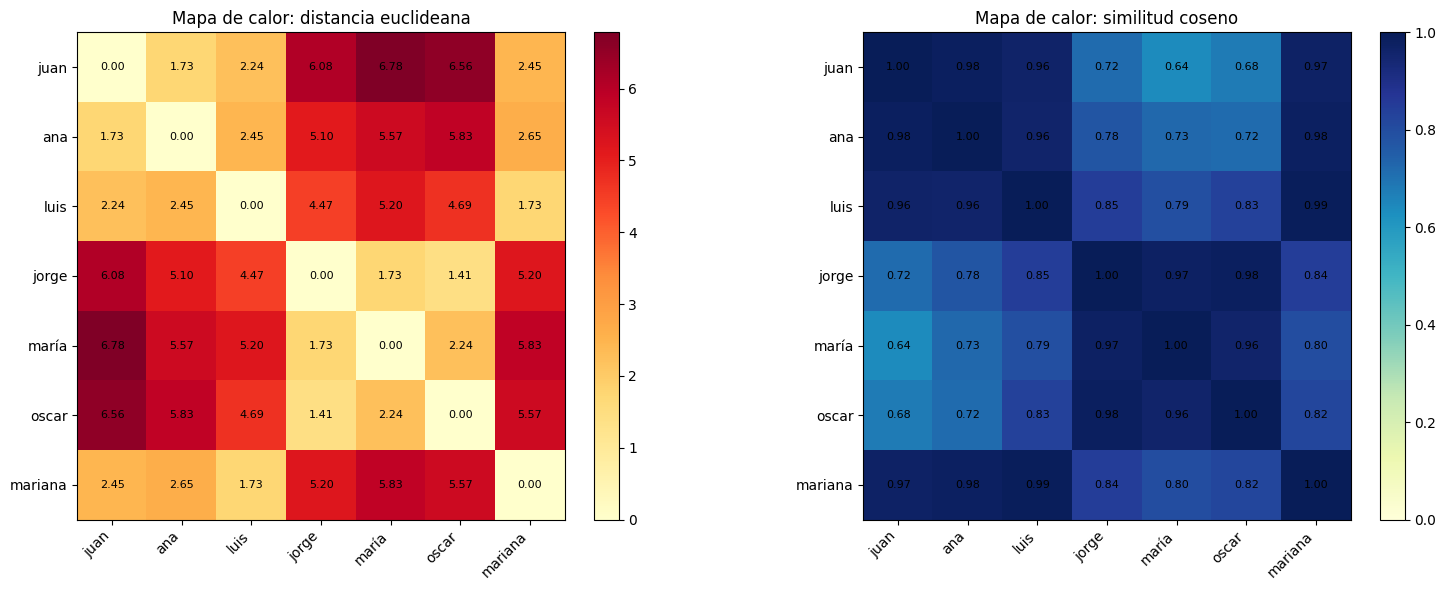

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mapa_distancias = axes[0].imshow(
    resultados_ejercicio_5['matriz_distancias_euclideanas'].values,
    cmap='YlOrRd',
)
axes[0].set_title('Mapa de calor: distancia euclideana')
axes[0].set_xticks(range(len(usuarios)))
axes[0].set_yticks(range(len(usuarios)))
axes[0].set_xticklabels(usuarios, rotation=45, ha='right')
axes[0].set_yticklabels(usuarios)

for i in range(len(usuarios)):
    for j in range(len(usuarios)):
        axes[0].text(
            j,
            i,
            f"{resultados_ejercicio_5['matriz_distancias_euclideanas'].iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=8,
        )

fig.colorbar(mapa_distancias, ax=axes[0], fraction=0.046, pad=0.04)

mapa_coseno = axes[1].imshow(
    resultados_ejercicio_5['matriz_similitud_coseno'].values,
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
)
axes[1].set_title('Mapa de calor: similitud coseno')
axes[1].set_xticks(range(len(usuarios)))
axes[1].set_yticks(range(len(usuarios)))
axes[1].set_xticklabels(usuarios, rotation=45, ha='right')
axes[1].set_yticklabels(usuarios)

for i in range(len(usuarios)):
    for j in range(len(usuarios)):
        axes[1].text(
            j,
            i,
            f"{resultados_ejercicio_5['matriz_similitud_coseno'].iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black',
            fontsize=8,
        )

fig.colorbar(mapa_coseno, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**Solucion del ejercicio 5**

- La matriz de distancias euclideanas muestra que `jorge` y `oscar` son los usuarios mas cercanos (`1.414214`), mientras que `juan` y `maría` son los mas distantes (`6.782330`).
- La matriz de similitud coseno muestra la mayor similitud entre `luis` y `mariana` (`0.991515`), y la menor entre `juan` y `maría` (`0.640102`).

**Interpretacion de las medidas**

- La distancia euclideana compara diferencias absolutas en las calificaciones pelicula por pelicula.
- La similitud coseno compara el patron relativo de gustos, por eso mide que tan parecidas son las preferencias aunque los puntajes no coincidan exactamente.
- En este ejercicio no es necesario normalizar para calcular las distancias porque todas las variables ya estan en la misma escala de `1` a `5`, asi que ninguna pelicula domina a las demas por unidad de medida.
- La normalizacion seria necesaria si hubiera variables con escalas distintas o magnitudes mucho mayores.


**Ejercicio 6**


Se tiene el siguiente conjunto de datos:

In [33]:
titulos = ['usuario','edad','altura','peso','ciudad','genero']
puntajes = [['juan',19,1.70,60,'Bogotá','M'],
            ['ana',22,1.68,58,'Cali','F'],
            ['luis',25,1.81,70,'Bogotá','M'],
            ['jorge',24,1.78,71,'Medellín','M'],
            ['maría',24,1.65,68,'Cali','F'],
            ['oscar',20,1.72,71,'Medellín','M'],
            ['mariana',23,1.55,65,'Bogotá','F']]
personas = pd.DataFrame(puntajes,columns=titulos)
personas

,usuario,edad,altura,peso,ciudad,genero
0,juan,19,1.70,60,Bogotá,M
1,ana,22,1.68,58,Cali,F
2,luis,25,1.81,70,Bogotá,M
3,jorge,24,1.78,71,Medellín,M
4,maría,24,1.65,68,Cali,F
5,oscar,20,1.72,71,Medellín,M
6,mariana,23,1.55,65,Bogotá,F


*   Calcular la similaridad de Gower
*   Calcular la similitud combinando pesos a cada uno de los atributos.

In [ ]:
perfil_personas = personas.set_index('usuario')
usuarios = perfil_personas.index.tolist()

atributos_numericos = ['edad', 'altura', 'peso']
atributos_categoricos = ['ciudad', 'genero']

rangos_numericos = {
    atributo: perfil_personas[atributo].max() - perfil_personas[atributo].min()
    for atributo in atributos_numericos
}

pesos_atributos = {
    'edad': 1,
    'altura': 1,
    'peso': 1,
    'ciudad': 1,
    'genero': 1,
}

def gower_similarity(fila_a, fila_b, pesos=None):
    if pesos is None:
        pesos = {atributo: 1 for atributo in atributos_numericos + atributos_categoricos}

    suma_similitudes = 0
    suma_pesos = 0

    for atributo in atributos_numericos:
        rango = rangos_numericos[atributo]
        similitud = 1 - abs(fila_a[atributo] - fila_b[atributo]) / rango
        suma_similitudes += pesos[atributo] * similitud
        suma_pesos += pesos[atributo]

    for atributo in atributos_categoricos:
        similitud = 1 if fila_a[atributo] == fila_b[atributo] else 0
        suma_similitudes += pesos[atributo] * similitud
        suma_pesos += pesos[atributo]

    return suma_similitudes / suma_pesos

matriz_gower = []
matriz_gower_ponderada = []

for usuario_a in usuarios:
    fila_a = perfil_personas.loc[usuario_a]
    similitudes_base = []
    similitudes_ponderadas = []
    for usuario_b in usuarios:
        fila_b = perfil_personas.loc[usuario_b]
        similitudes_base.append(gower_similarity(fila_a, fila_b))
        similitudes_ponderadas.append(gower_similarity(fila_a, fila_b, pesos_atributos))
    matriz_gower.append(similitudes_base)
    matriz_gower_ponderada.append(similitudes_ponderadas)

matriz_similitud_gower = pd.DataFrame(
    matriz_gower,
    index=usuarios,
    columns=usuarios,
)
matriz_similitud_gower_ponderada = pd.DataFrame(
    matriz_gower_ponderada,
    index=usuarios,
    columns=usuarios,
)

resultados_ejercicio_6 = {
    'rangos_numericos': rangos_numericos,
    'pesos_atributos': pesos_atributos,
    'matriz_similitud_gower': matriz_similitud_gower.round(6),
    'matriz_similitud_gower_ponderada': matriz_similitud_gower_ponderada.round(6),
}

print(f"Rangos numericos = {resultados_ejercicio_6['rangos_numericos']}")
print(f"Pesos usados = {resultados_ejercicio_6['pesos_atributos']}")
print()
print('Matriz de similitud de Gower')
print(resultados_ejercicio_6['matriz_similitud_gower'].to_string())
print()
print('Matriz de similitud de Gower ponderada')
print(resultados_ejercicio_6['matriz_similitud_gower_ponderada'].to_string())


**Solucion del ejercicio 6**

- La similitud de Gower permite comparar usuarios con atributos mixtos: numericos (`edad`, `altura`, `peso`) y categoricos (`ciudad`, `genero`).
- Los rangos usados para normalizar los atributos numericos son `edad = 6`, `altura = 0.26` y `peso = 13`.
- En la matriz de Gower, el par mas similar es `jorge-oscar` con `0.820513`, mientras que el menos similar es `ana-luis` con `0.215385`.
- La matriz ponderada usa pesos iguales para todos los atributos, por lo que conserva la misma estructura de similitud que la matriz base de Gower.

**Interpretacion de las medidas**

- En los atributos numericos, Gower compara la diferencia relativa respecto al rango de cada variable, evitando que una magnitud mas grande domine a las demas.
- En los atributos categoricos, la similitud es `1` si ambos usuarios coinciden y `0` si son diferentes.
- Gower es apropiada en este ejercicio porque combina en una sola medida informacion numerica y nominal.
- Si en otro contexto algunos atributos fueran mas importantes que otros, bastaria con cambiar los pesos para que influyan mas en la similitud final.
